# Práctica 09: Algoritmos de Análisis No Supervisado
## Clientes de Centros Comerciales — K-Means & EDA

---

| Campo | Detalle |
|:------|:--------|
| **Institución** | Universidad Tecnologica de Xicotepec de Juarez |
| **Asignatura** | Extraccion de Conocimiento en Bases de Datos |
| **Unidad** | Unidad 4 |
| **Estudiante** | Francisco Garcia Garcia |
| **Matrícula** | 230758 |
| **Grupo** | 9°A — IDGS |
| **Fecha** |10 Agosto 2026 |
| **Notebook Original** | [Unsupervised Learning: 3-6 Clusters \| K-Means \| EDA (Kaggle)](https://www.kaggle.com/code/tanmay111999/unsupervised-learning-3-6-clusters-k-means-eda) |

---

**Objetivo:** Aplicar las etapas fundamentales de un proceso de aprendizaje no supervisado para la segmentación de clientes de un centro comercial, utilizando el algoritmo K-Means sobre el dataset `Mall_Customers.csv`.

##  Introducción

> ###  ESPACIO PARA EL ESTUDIANTE — Redacta tu introducción
> 
> **Instrucciones:** Escribe con tus propias palabras una introducción que cubra los siguientes puntos:
> 
> 1. **¿Qué es el aprendizaje no supervisado?** — Explica brevemente en qué se diferencia del aprendizaje supervisado (pista: no hay etiquetas/respuestas conocidas).
> 2. **¿Qué problema resuelve el agrupamiento (clustering)?** — Menciona que busca encontrar grupos naturales en los datos sin información previa.
> 3. **¿Cuál es el propósito de aplicar K-Means en la segmentación de clientes?** — Explica por qué un centro comercial querría agrupar a sus clientes (pista: estrategias de marketing personalizadas).
> 
> **Ejemplo de redacción (puedes modificarlo o reescribirlo completamente):**
> 
> *El aprendizaje no supervisado es una rama del machine learning donde los algoritmos trabajan con datos que no tienen etiquetas predefinidas. A diferencia del aprendizaje supervisado, donde el modelo aprende a partir de ejemplos con respuestas conocidas, aquí el objetivo es descubrir patrones ocultos en los datos por sí mismo...*

## Importación de Librerías

Se importan las librerías necesarias para el análisis:

- **Pandas:** Manipulación y análisis de datos tabulares (DataFrames).
- **NumPy:** Operaciones numéricas y manejo de arreglos.
- **Matplotlib & Seaborn:** Creación de visualizaciones estáticas y gráficos estadísticos.
- **Scikit-learn (sklearn):** Algoritmos de machine learning, incluyendo `KMeans`, `StandardScaler`, `LabelEncoder` y métricas como `silhouette_score`.

In [1]:
# ============================================================
# Importación de Librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn: Preprocesamiento y Modelado
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

# Configuración general
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


##  Versiones del Entorno de Trabajo

Registramos las versiones de las librerías principales para garantizar la reproducibilidad del notebook.

In [2]:
# ============================================================
# Registro de Versiones del Entorno
# ============================================================
import sys
import sklearn

print(f' Python:       {sys.version.split()[0]}')
print(f' Pandas:       {pd.__version__}')
print(f' NumPy:        {np.__version__}')
print(f' Matplotlib:   {plt.matplotlib.__version__}')
print(f' Seaborn:      {sns.__version__}')
print(f' Scikit-learn: {sklearn.__version__}')

 Python:       3.11.0
 Pandas:       2.2.2
 NumPy:        2.3.1
 Matplotlib:   3.11.0
 Seaborn:      0.13.2
 Scikit-learn: 1.9.0


##  Carga del Dataset

El dataset `Mall_Customers.csv` contiene información recolectada de 200 clientes de un centro comercial. Fue obtenido originalmente de Kaggle (*Mall Customer Segmentation Data*).

Se utiliza `pd.read_csv()` para cargar los datos en un DataFrame.

In [3]:
# ============================================================
# Carga del Dataset
# ============================================================
df_clientes = pd.read_csv('Mall_Customers.csv')

print(f' Dataset cargado exitosamente')
print(f'    Registros: {df_clientes.shape[0]}')
print(f'    Columnas:  {df_clientes.shape[1]}')

 Dataset cargado exitosamente
    Registros: 200
    Columnas:  5


### Primeras Observaciones (`head`)

In [4]:
# Primeras 10 filas del dataset
df_clientes.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### Últimas Observaciones (`tail`)

In [5]:
# Últimas 10 filas del dataset
df_clientes.tail(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


##  Estructura del Dataset

Se analiza la estructura interna del DataFrame: tipos de datos, número de registros por columna y consumo de memoria.

In [6]:
# ============================================================
# Estructura del Dataset
# ============================================================
print('=' * 60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('=' * 60)
df_clientes.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


##  Descripción de las Variables

> ###  ESPACIO PARA EL ESTUDIANTE — Describe las variables
> 
> **Instrucciones:** Completa la descripción de cada variable con tus propias palabras:
> 
> | Variable | Tipo | Descripción |
> |:---------|:-----|:------------|
> | `CustomerID` | int64 | Identificador único de cada cliente (1 a 200). |
> | `Gender` | object | Género del cliente: Male (Masculino) o Female (Femenino). |
> | `Age` | int64 | *(Escribe aquí qué representa esta variable y su rango)* |
> | `Annual Income (k$)` | int64 | *(Escribe aquí qué representa y en qué unidades está)* |
> | `Spending Score (1-100)` | int64 | *(Escribe aquí qué es el puntaje de gasto y quién lo asigna)* |

##  Revisión de Calidad de los Datos

Verificamos la existencia de valores nulos, registros duplicados, valores únicos y rangos para asegurar la integridad de los datos antes de analizarlos.

In [7]:
# ============================================================
# Revisión de Calidad de Datos
# ============================================================

# 1. Valores nulos por columna
print(' Valores Nulos por Columna:')
print(df_clientes.isnull().sum())
print(f'\n   Total de nulos en el dataset: {df_clientes.isnull().sum().sum()}')

print('\n' + '=' * 60)

# 2. Registros duplicados
duplicados = df_clientes.duplicated().sum()
print(f' Registros Duplicados: {duplicados}')

print('\n' + '=' * 60)

# 3. Valores únicos por columna
print(' Valores Únicos por Columna:')
print(df_clientes.nunique())

print('\n' + '=' * 60)

# 4. Rangos de las variables numéricas
print(' Rangos de Variables Numéricas:')
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    print(f'   {col}: [{df_clientes[col].min()} - {df_clientes[col].max()}]')

 Valores Nulos por Columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

   Total de nulos en el dataset: 0

 Registros Duplicados: 0

 Valores Únicos por Columna:
CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

 Rangos de Variables Numéricas:
   Age: [18 - 70]
   Annual Income (k$): [15 - 137]
   Spending Score (1-100): [1 - 99]


> ###  ESPACIO PARA EL ESTUDIANTE — Interpretación de la calidad de datos
> 
> **Instrucciones:** Responde brevemente:
> - ¿Se encontraron valores nulos? ¿Se requiere imputación?
> - ¿Hay registros duplicados? ¿Qué implicaría si los hubiera?
> - ¿Los rangos de las variables son coherentes o hay valores fuera de rango?

##  Estadísticas Descriptivas

Se calculan las medidas de tendencia central (media, mediana), dispersión (desviación estándar, rango) y posición (cuartiles) para las variables numéricas.

In [8]:
# ============================================================
# Estadísticas Descriptivas
# ============================================================
df_clientes.describe().T.style.background_gradient(cmap='YlOrRd').format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.00,100.50,57.88,1.00,50.75,100.50,150.25,200.00
Age,200.00,38.85,13.97,18.00,28.75,36.00,49.00,70.00
Annual Income (k$),200.00,60.56,26.26,15.00,41.50,61.50,78.00,137.00
Spending Score (1-100),200.00,50.20,25.82,1.00,34.75,50.00,73.00,99.00


> ###  ESPACIO PARA EL ESTUDIANTE — Interpretación de estadísticas descriptivas
> 
> **Instrucciones:** Interpreta los resultados de `describe()`. Responde:
> - ¿Cuál es la edad promedio de los clientes? ¿Qué rango de edades predomina (observa Q1 y Q3)?
> - ¿Cuál es el ingreso anual promedio y su desviación estándar? ¿Qué indica esa dispersión?
> - ¿El puntaje de gasto (Spending Score) tiende a concentrarse en valores altos o bajos? ¿Qué indica la mediana (50%)?

##  Nota sobre la Traducción

Este notebook está basado en el trabajo original de **tanmay111999** en Kaggle: *"Unsupervised Learning: 3-6 Clusters | K-Means | EDA"*. Todo el contenido ha sido traducido al español, reestructurado con nombres de variables propios y enriquecido con explicaciones e interpretaciones adicionales del estudiante. Los términos técnicos en inglés se conservan entre paréntesis cuando es necesario para mantener la claridad: *K-Means*, *clustering*, *elbow method*, *silhouette score*, *WCSS (Within-Cluster Sum of Squares)*, etc.

##  Análisis Exploratorio Univariado (EDA)

### Distribución por Género

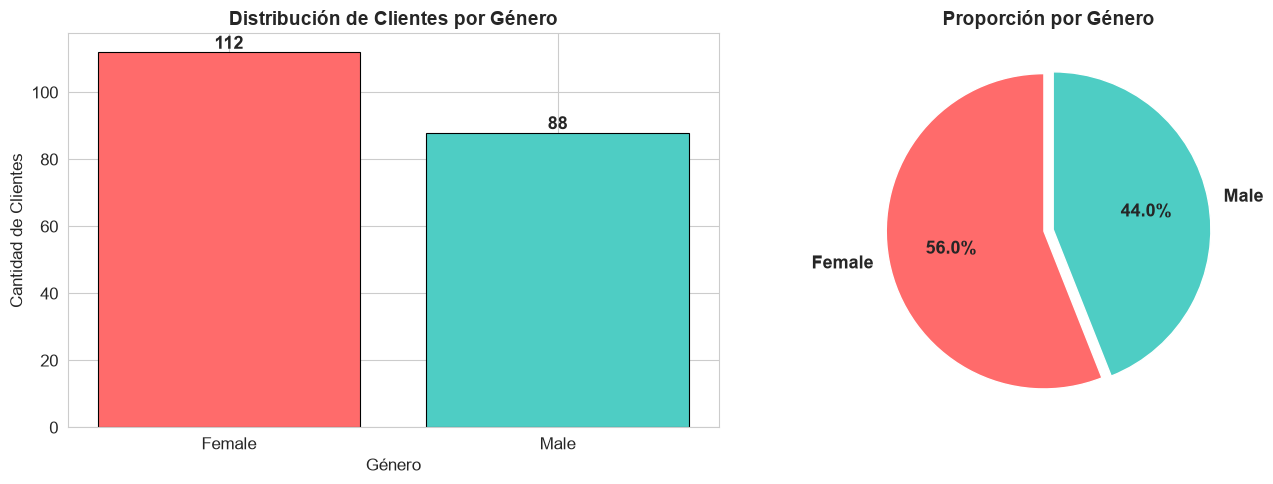


 Resumen: 112 mujeres (56.0%) y 88 hombres (44.0%)


In [9]:
# ============================================================
# Distribución por Género
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
conteo_genero = df_clientes['Gender'].value_counts()
colors_gen = ['#FF6B6B', '#4ECDC4']
axes[0].bar(conteo_genero.index, conteo_genero.values, color=colors_gen, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de Clientes por Género', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(conteo_genero.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=13)

# Gráfico de pastel
axes[1].pie(conteo_genero.values, labels=conteo_genero.index, autopct='%1.1f%%',
            colors=colors_gen, startangle=90, explode=(0.03, 0.03),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Proporción por Género', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n Resumen: {conteo_genero["Female"]} mujeres ({conteo_genero["Female"]/len(df_clientes)*100:.1f}%) y {conteo_genero["Male"]} hombres ({conteo_genero["Male"]/len(df_clientes)*100:.1f}%)')

### Distribución de Edad

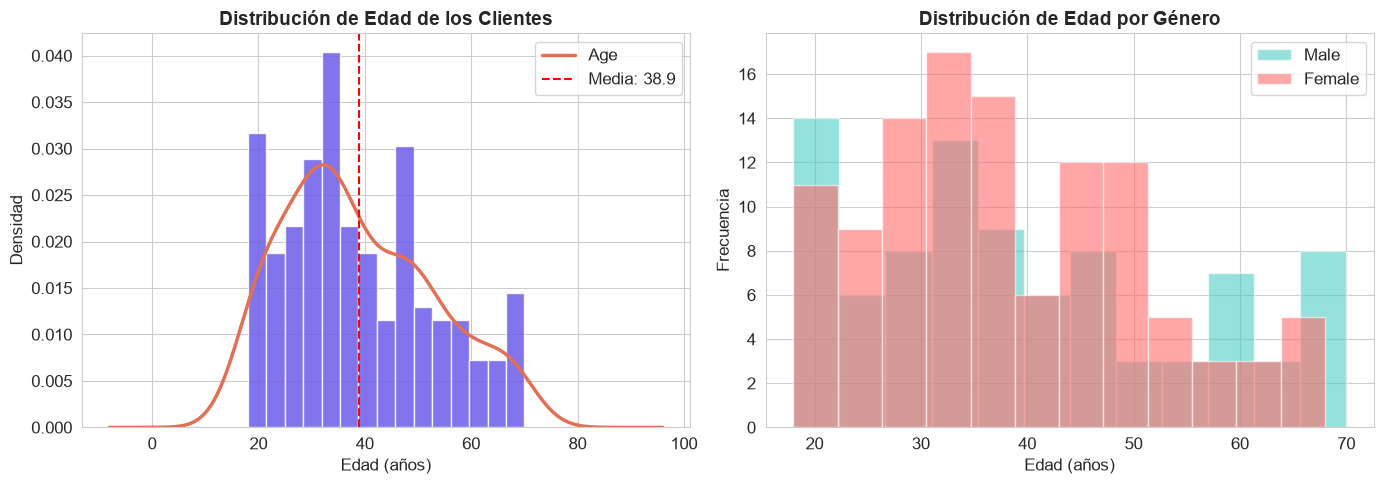

In [10]:
# ============================================================
# Distribución de Edad
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
axes[0].hist(df_clientes['Age'], bins=15, color='#6C5CE7', edgecolor='white', alpha=0.85, density=True)
df_clientes['Age'].plot(kind='kde', ax=axes[0], color='#E17055', linewidth=2.5)
axes[0].set_title('Distribución de Edad de los Clientes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Densidad')
axes[0].axvline(df_clientes['Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df_clientes["Age"].mean():.1f}')
axes[0].legend()

# Histograma por género
for genero, color in zip(['Male', 'Female'], ['#4ECDC4', '#FF6B6B']):
    subset = df_clientes[df_clientes['Gender'] == genero]['Age']
    axes[1].hist(subset, bins=12, alpha=0.6, color=color, edgecolor='white', label=genero)
axes[1].set_title('Distribución de Edad por Género', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### Distribución de Ingreso Anual

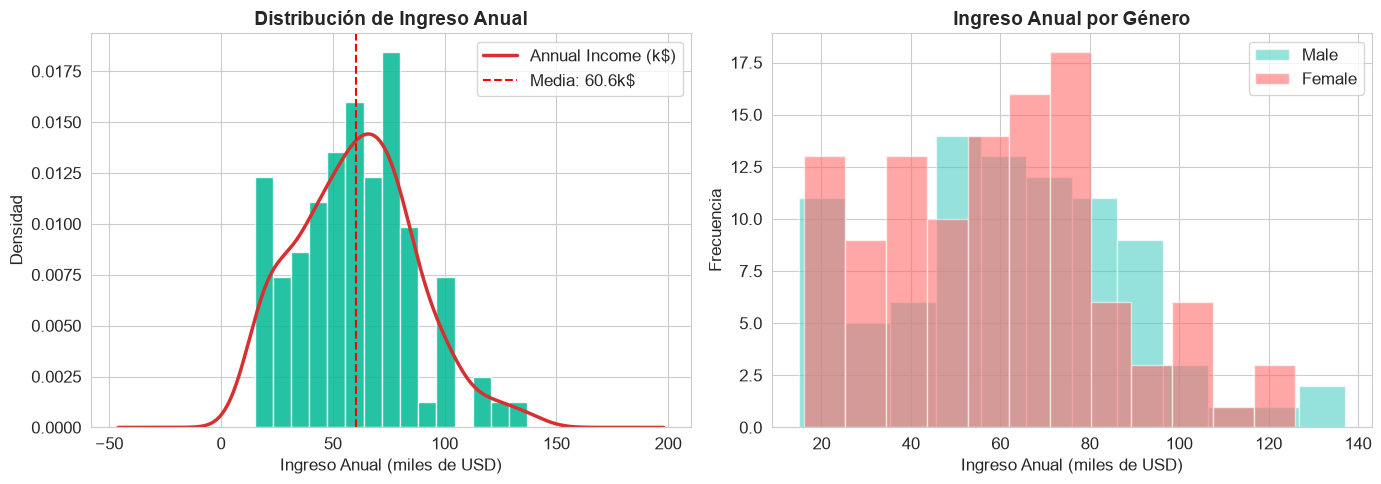

In [11]:
# ============================================================
# Distribución de Ingreso Anual
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clientes['Annual Income (k$)'], bins=15, color='#00B894', edgecolor='white', alpha=0.85, density=True)
df_clientes['Annual Income (k$)'].plot(kind='kde', ax=axes[0], color='#D63031', linewidth=2.5)
axes[0].set_title('Distribución de Ingreso Anual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ingreso Anual (miles de USD)')
axes[0].set_ylabel('Densidad')
axes[0].axvline(df_clientes['Annual Income (k$)'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df_clientes["Annual Income (k$)"].mean():.1f}k$')
axes[0].legend()

# Por género
for genero, color in zip(['Male', 'Female'], ['#4ECDC4', '#FF6B6B']):
    subset = df_clientes[df_clientes['Gender'] == genero]['Annual Income (k$)']
    axes[1].hist(subset, bins=12, alpha=0.6, color=color, edgecolor='white', label=genero)
axes[1].set_title('Ingreso Anual por Género', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ingreso Anual (miles de USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### Distribución de Puntuación de Gasto (Spending Score)

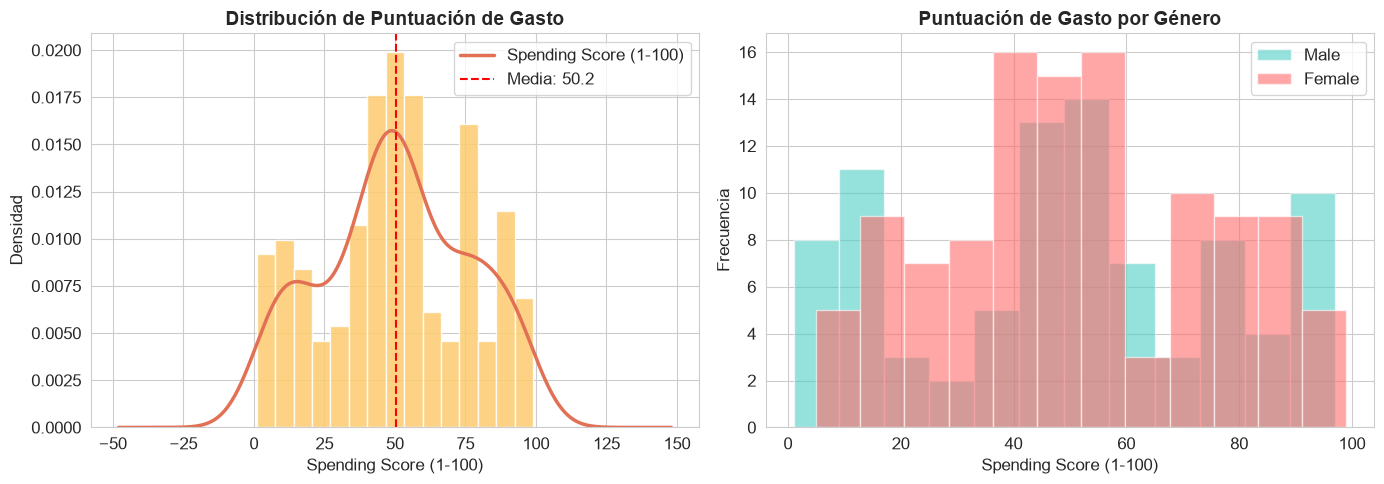

In [12]:
# ============================================================
# Distribución de Puntuación de Gasto
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clientes['Spending Score (1-100)'], bins=15, color='#FDCB6E', edgecolor='white', alpha=0.85, density=True)
df_clientes['Spending Score (1-100)'].plot(kind='kde', ax=axes[0], color='#E17055', linewidth=2.5)
axes[0].set_title('Distribución de Puntuación de Gasto', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Spending Score (1-100)')
axes[0].set_ylabel('Densidad')
axes[0].axvline(df_clientes['Spending Score (1-100)'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df_clientes["Spending Score (1-100)"].mean():.1f}')
axes[0].legend()

# Por género
for genero, color in zip(['Male', 'Female'], ['#4ECDC4', '#FF6B6B']):
    subset = df_clientes[df_clientes['Gender'] == genero]['Spending Score (1-100)']
    axes[1].hist(subset, bins=12, alpha=0.6, color=color, edgecolor='white', label=genero)
axes[1].set_title('Puntuación de Gasto por Género', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Spending Score (1-100)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

> ###  ESPACIO PARA EL ESTUDIANTE — Interpretación de las distribuciones
> 
> **Instrucciones:** Observa las gráficas anteriores y redacta tus observaciones:
> - ¿Qué grupo de edad es el más frecuente entre los clientes?
> - ¿Cómo se distribuye el ingreso anual? ¿Es simétrica o sesgada?
> - ¿Qué patrón observas en la puntuación de gasto? ¿Se concentra en algún rango?
> - ¿Hay diferencias notables entre hombres y mujeres en alguna variable?

##  Detección de Valores Atípicos (Boxplots)

Los diagramas de caja (*boxplots*) permiten identificar valores atípicos (*outliers*) que se encuentran fuera del rango intercuartílico (IQR = Q3 - Q1).

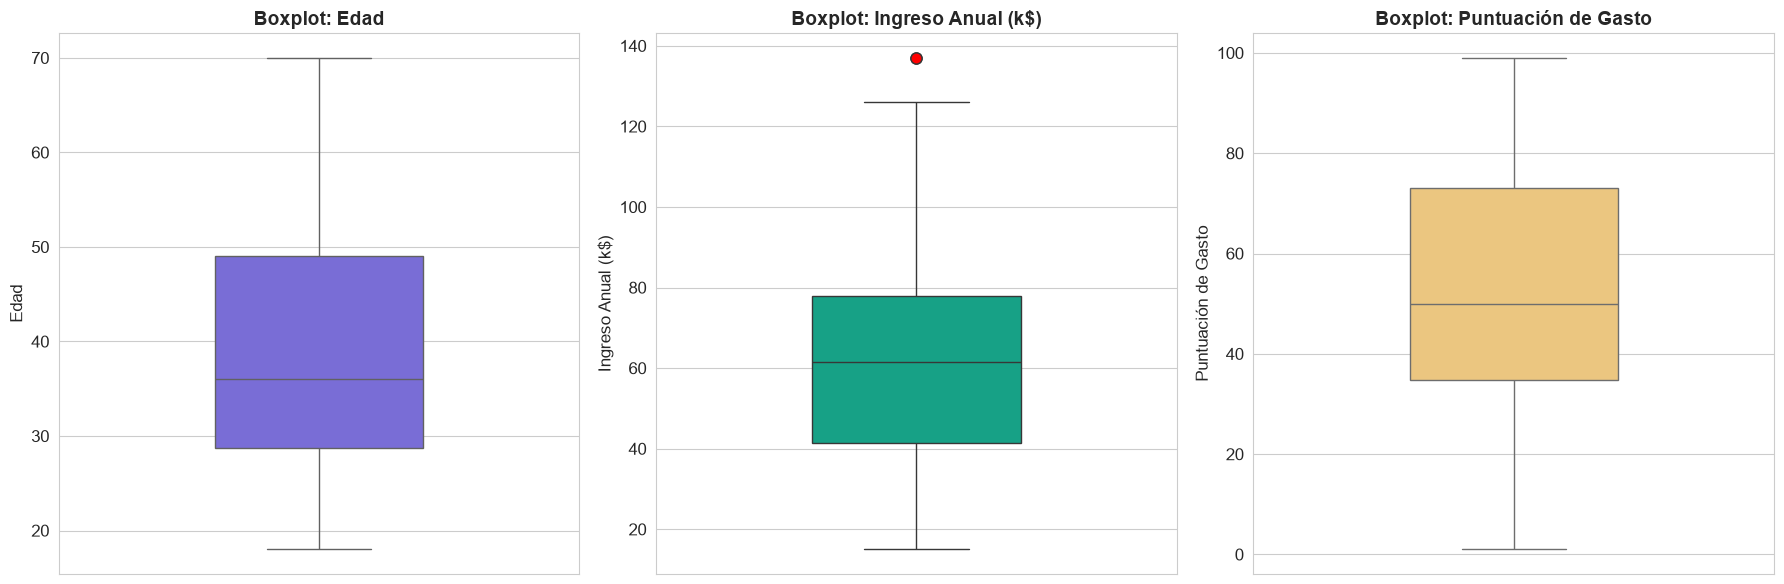

In [13]:
# ============================================================
# Diagramas de Caja (Boxplots)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colores = ['#6C5CE7', '#00B894', '#FDCB6E']
titulos = ['Edad', 'Ingreso Anual (k$)', 'Puntuación de Gasto']

for i, (var, color, titulo) in enumerate(zip(variables, colores, titulos)):
    sns.boxplot(data=df_clientes, y=var, ax=axes[i], color=color, width=0.4,
                flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8})
    axes[i].set_title(f'Boxplot: {titulo}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(titulo)

plt.tight_layout()
plt.show()

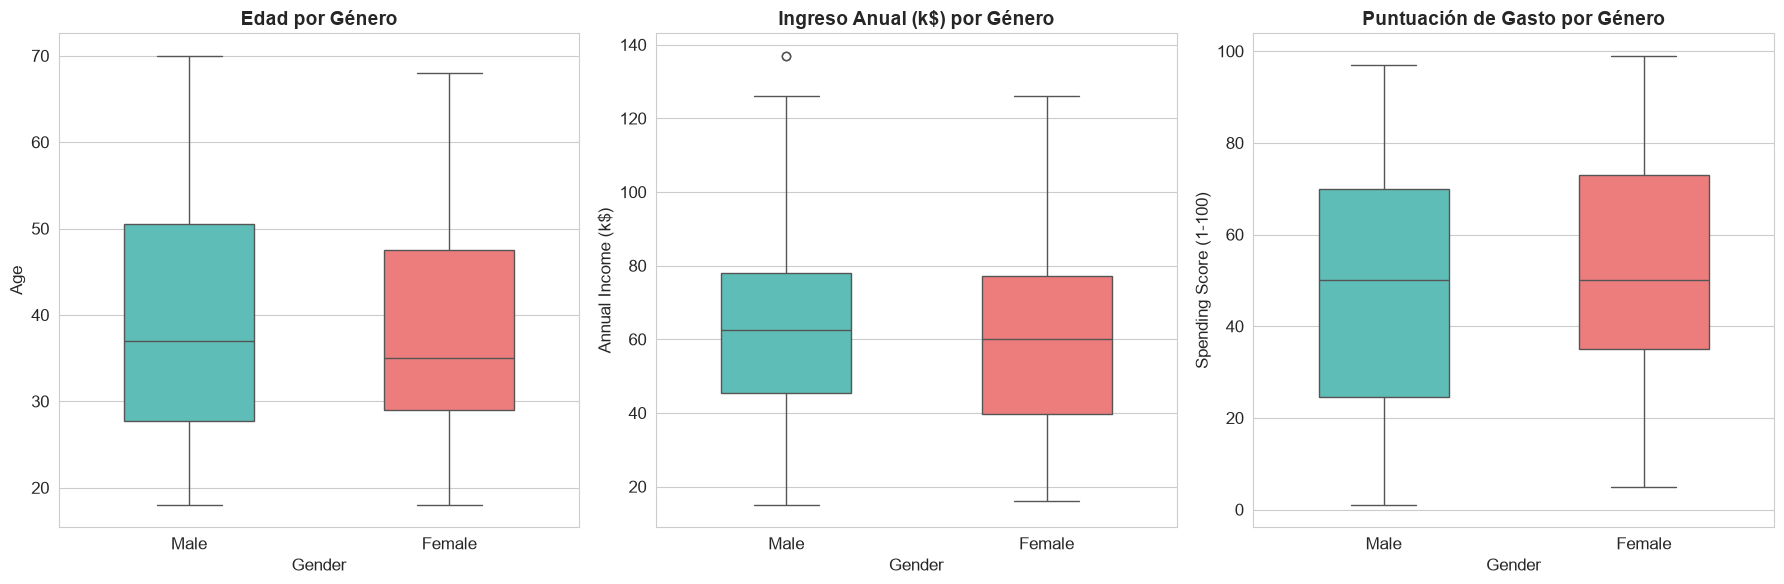

In [14]:
# ============================================================
# Boxplots comparativos por Género
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    sns.boxplot(data=df_clientes, x='Gender', y=var, ax=axes[i],
                palette={'Male': '#4ECDC4', 'Female': '#FF6B6B'}, width=0.5)
    axes[i].set_title(f'{titulo} por Género', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

> ###  ESPACIO PARA EL ESTUDIANTE — Interpretación de boxplots
> 
> **Instrucciones:** Responde:
> - ¿Se detectaron valores atípicos (outliers) en alguna variable? ¿En cuál?
> - ¿Existen diferencias significativas entre géneros en términos de ingreso o gasto?
> - ¿Los outliers representan errores de captura o son clientes con características extremas legítimas?

##  Análisis Bivariado y Multivariado

### Gráfico de Pares (Pairplot)

El pairplot muestra las relaciones entre pares de variables numéricas, coloreadas por género.

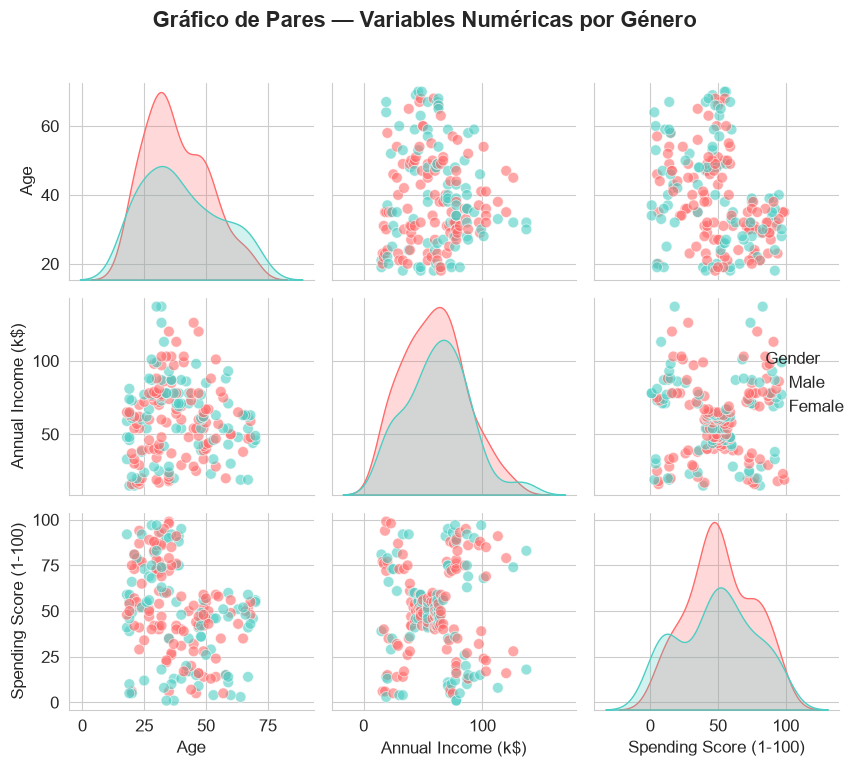

In [15]:
# ============================================================
# Pairplot por Género
# ============================================================
sns.pairplot(df_clientes, hue='Gender', vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
             palette={'Male': '#4ECDC4', 'Female': '#FF6B6B'},
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 60, 'edgecolor': 'white'})
plt.suptitle('Gráfico de Pares — Variables Numéricas por Género', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de Correlación

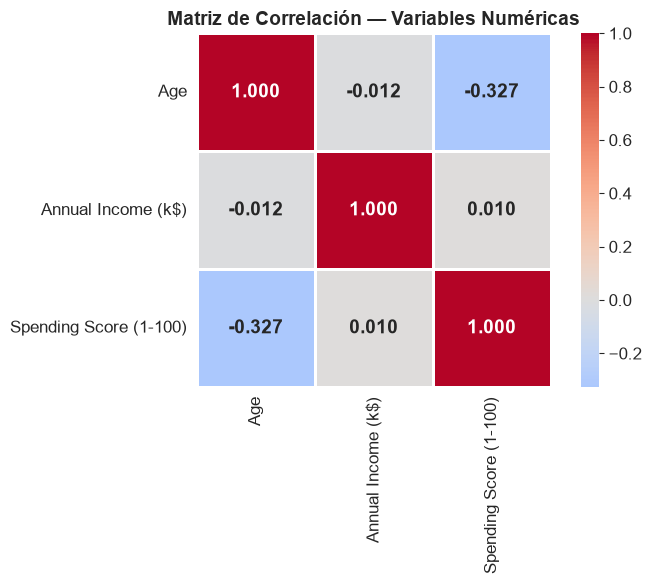


 Interpretación rápida de correlaciones:
   • Age vs Annual Income (k$): r = -0.012 (correlación débil negativa)
   • Age vs Spending Score (1-100): r = -0.327 (correlación moderada negativa)
   • Annual Income (k$) vs Spending Score (1-100): r = 0.010 (correlación débil positiva)


In [16]:
# ============================================================
# Matriz de Correlación
# ============================================================
columnas_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
correlacion = df_clientes[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=2, linecolor='white', square=True,
            annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Interpretación rápida de correlaciones:')
for i in range(len(columnas_numericas)):
    for j in range(i+1, len(columnas_numericas)):
        r = correlacion.iloc[i, j]
        fuerza = 'débil' if abs(r) < 0.3 else ('moderada' if abs(r) < 0.7 else 'fuerte')
        direccion = 'positiva' if r > 0 else 'negativa'
        print(f'   • {columnas_numericas[i]} vs {columnas_numericas[j]}: r = {r:.3f} (correlación {fuerza} {direccion})')

> ###  ESPACIO PARA EL ESTUDIANTE — Interpretación del análisis bivariado
> 
> **Instrucciones:** Analiza el pairplot y la matriz de correlación:
> - ¿Qué par de variables muestra algún patrón interesante en el pairplot?
> - ¿Las correlaciones son fuertes, moderadas o débiles? ¿Qué implica esto para el clustering?
> - ¿Observas alguna agrupación visual en los scatter plots del pairplot? (Pista: observa Ingreso vs. Gasto)

##  Codificación de la Variable Categórica `Gender`

Para incluir la variable `Gender` en análisis numéricos, se utiliza `LabelEncoder` de Scikit-learn para convertirla en valores numéricos.

> **Importante:** La codificación numérica (0 = Female, 1 = Male) **no implica un orden jerárquico** ni que un género sea "mayor" que otro. Es simplemente una representación numérica necesaria para los algoritmos de machine learning.

In [17]:
# ============================================================
# Codificación de Gender con LabelEncoder
# ============================================================
codificador = LabelEncoder()
df_clientes['Gender_cod'] = codificador.fit_transform(df_clientes['Gender'])

print('📌 Mapeo de codificación:')
for clase, codigo in zip(codificador.classes_, codificador.transform(codificador.classes_)):
    print(f'   {clase} → {codigo}')

print(f'\n✅ Nueva columna "Gender_cod" agregada al DataFrame')
df_clientes[['Gender', 'Gender_cod']].head(10)

📌 Mapeo de codificación:
   Female → 0
   Male → 1

✅ Nueva columna "Gender_cod" agregada al DataFrame


,Gender,Gender_cod
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


## ⚖️ Normalización de Variables Numéricas

Se aplica `StandardScaler` de Scikit-learn para normalizar las variables numéricas. Esto transforma cada variable para que tenga **media = 0** y **desviación estándar = 1**, lo cual es importante porque K-Means utiliza la distancia euclidiana, y variables con rangos muy diferentes (por ejemplo, ingreso en decenas vs. edad en unidades) dominarían injustamente el cálculo de distancias.

In [18]:
# ============================================================
# Normalización con StandardScaler
# ============================================================
columnas_a_escalar = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
escalador = StandardScaler()

df_normalizado = df_clientes.copy()
df_normalizado[columnas_a_escalar] = escalador.fit_transform(df_clientes[columnas_a_escalar])

print('📌 Comparación: Datos Originales vs. Normalizados\n')
print('--- ORIGINALES ---')
print(df_clientes[columnas_a_escalar].describe().round(2))
print('\n--- NORMALIZADOS ---')
print(df_normalizado[columnas_a_escalar].describe().round(2))

📌 Comparación: Datos Originales vs. Normalizados

--- ORIGINALES ---
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97               26.26                   25.82
min     18.00               15.00                    1.00
25%     28.75               41.50                   34.75
50%     36.00               61.50                   50.00
75%     49.00               78.00                   73.00
max     70.00              137.00                   99.00

--- NORMALIZADOS ---
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    -0.00               -0.00                   -0.00
std      1.00                1.00                    1.00
min     -1.50               -1.74                   -1.91
25%     -0.72               -0.73                   -0.60
50%     -0.20                0.04      

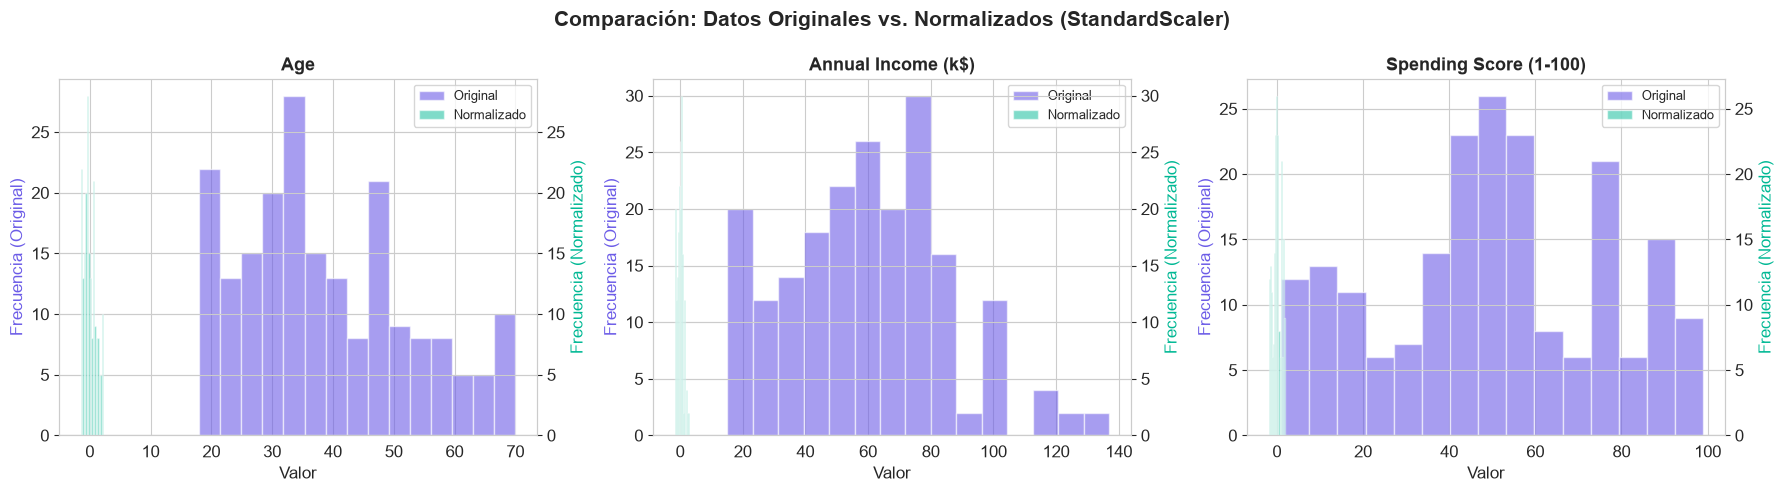

In [19]:
# ============================================================
# Comparación Visual: Originales vs. Normalizados
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(columnas_a_escalar):
    axes[i].hist(df_clientes[col], bins=15, alpha=0.6, color='#6C5CE7', label='Original', edgecolor='white')
    ax2 = axes[i].twinx()
    ax2.hist(df_normalizado[col], bins=15, alpha=0.5, color='#00B894', label='Normalizado', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia (Original)', color='#6C5CE7')
    ax2.set_ylabel('Frecuencia (Normalizado)', color='#00B894')
    
    # Leyenda combinada
    lines1, labels1 = axes[i].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[i].legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.suptitle('Comparación: Datos Originales vs. Normalizados (StandardScaler)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧮 Construcción de Matrices de Características

Se preparan las matrices de características para aplicar K-Means sobre diferentes combinaciones de variables, tanto con datos **originales** como **normalizados**:

1. **Edad × Ingreso Anual** (*Age vs Annual Income*)
2. **Edad × Puntuación de Gasto** (*Age vs Spending Score*)
3. **Ingreso Anual × Puntuación de Gasto** (*Annual Income vs Spending Score*)

In [20]:
# ============================================================
# Matrices de Características (Datos Originales)
# ============================================================
X1_original = df_clientes[['Age', 'Annual Income (k$)']].values
X2_original = df_clientes[['Age', 'Spending Score (1-100)']].values
X3_original = df_clientes[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Matrices de Características (Datos Normalizados)
X1_normalizado = df_normalizado[['Age', 'Annual Income (k$)']].values
X2_normalizado = df_normalizado[['Age', 'Spending Score (1-100)']].values
X3_normalizado = df_normalizado[['Annual Income (k$)', 'Spending Score (1-100)']].values

combinaciones = {
    'Edad vs Ingreso Anual': (X1_original, X1_normalizado),
    'Edad vs Puntuación de Gasto': (X2_original, X2_normalizado),
    'Ingreso Anual vs Puntuación de Gasto': (X3_original, X3_normalizado)
}

print('✅ Matrices de Características Construidas:')
for nombre, (orig, norm) in combinaciones.items():
    print(f'   📊 {nombre}: {orig.shape} (original) | {norm.shape} (normalizado)')

✅ Matrices de Características Construidas:
   📊 Edad vs Ingreso Anual: (200, 2) (original) | (200, 2) (normalizado)
   📊 Edad vs Puntuación de Gasto: (200, 2) (original) | (200, 2) (normalizado)
   📊 Ingreso Anual vs Puntuación de Gasto: (200, 2) (original) | (200, 2) (normalizado)


## 📐 Determinación del Número Óptimo de Clústeres (K)

### Método del Codo (*Elbow Method*) y Coeficiente de Silueta (*Silhouette Score*)

Se evalúan dos métodos para determinar el valor óptimo de K:

1. **Método del Codo (WCSS):** Grafica la inercia (suma de las distancias cuadráticas de cada punto a su centroide asignado) para distintos valores de K. El "codo" indica el punto donde agregar más clústeres ya no reduce significativamente el error.

2. **Coeficiente de Silueta:** Mide qué tan bien separados están los clústeres. Un valor cercano a 1 indica clústeres bien definidos; cercano a 0 indica solapamiento.

In [21]:
# ============================================================
# Función: Evaluación del Codo y Silueta
# ============================================================
def evaluar_k_optimo(X, nombre, rango_k=range(2, 11)):
    """
    Calcula WCSS (inercia) y Silhouette Score para un rango de valores de K.
    Genera las gráficas del Método del Codo y Coeficiente de Silueta.
    """
    inercias = []
    siluetas = []
    
    for k in rango_k:
        modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
        etiquetas = modelo.fit_predict(X)
        inercias.append(modelo.inertia_)
        siluetas.append(silhouette_score(X, etiquetas))
    
    # Gráficas
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Método del Codo
    axes[0].plot(list(rango_k), inercias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_title(f'Método del Codo — {nombre}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Número de Clústeres (K)')
    axes[0].set_ylabel('WCSS (Inercia)')
    axes[0].grid(True, alpha=0.3)
    
    # Silueta
    axes[1].plot(list(rango_k), siluetas, 'rs-', linewidth=2, markersize=8)
    axes[1].set_title(f'Coeficiente de Silueta — {nombre}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Número de Clústeres (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True, alpha=0.3)
    
    # Marcar el K óptimo por silueta
    k_optimo = list(rango_k)[np.argmax(siluetas)]
    axes[1].axvline(k_optimo, color='green', linestyle='--', linewidth=1.5, label=f'K óptimo = {k_optimo}')
    axes[1].legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Tabla de resultados
    print(f'\n📊 Resultados para: {nombre}')
    print(f'{"K":>4} | {"WCSS (Inercia)":>16} | {"Silhouette Score":>16}')
    print('-' * 42)
    for k, w, s in zip(rango_k, inercias, siluetas):
        marker = ' ◄ ÓPTIMO' if k == k_optimo else ''
        print(f'{k:>4} | {w:>16.2f} | {s:>16.4f}{marker}')
    
    return k_optimo

print('🔍 Evaluando K óptimo para cada combinación de variables...\n')

🔍 Evaluando K óptimo para cada combinación de variables...



   EVALUACIÓN CON DATOS ORIGINALES (Sin Normalizar)


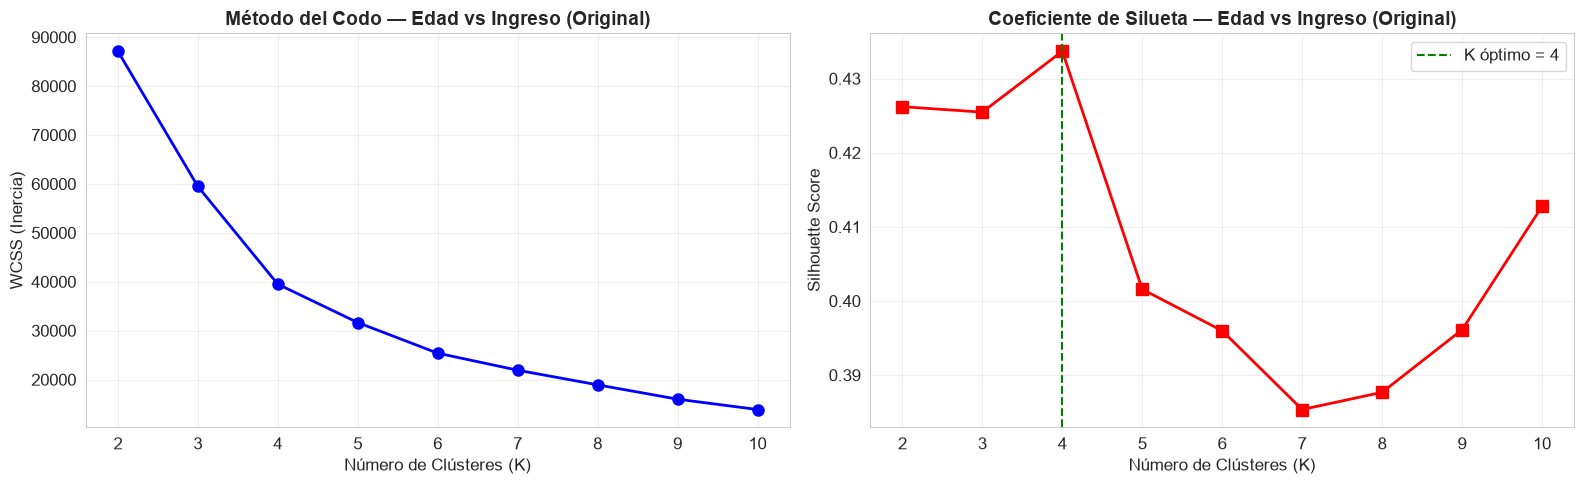


📊 Resultados para: Edad vs Ingreso (Original)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |         87121.57 |           0.4262
   3 |         59486.96 |           0.4255
   4 |         39502.78 |           0.4337 ◄ ÓPTIMO
   5 |         31659.35 |           0.4016
   6 |         25399.02 |           0.3960
   7 |         21917.57 |           0.3854
   8 |         18926.73 |           0.3877
   9 |         15993.24 |           0.3961
  10 |         13879.63 |           0.4127


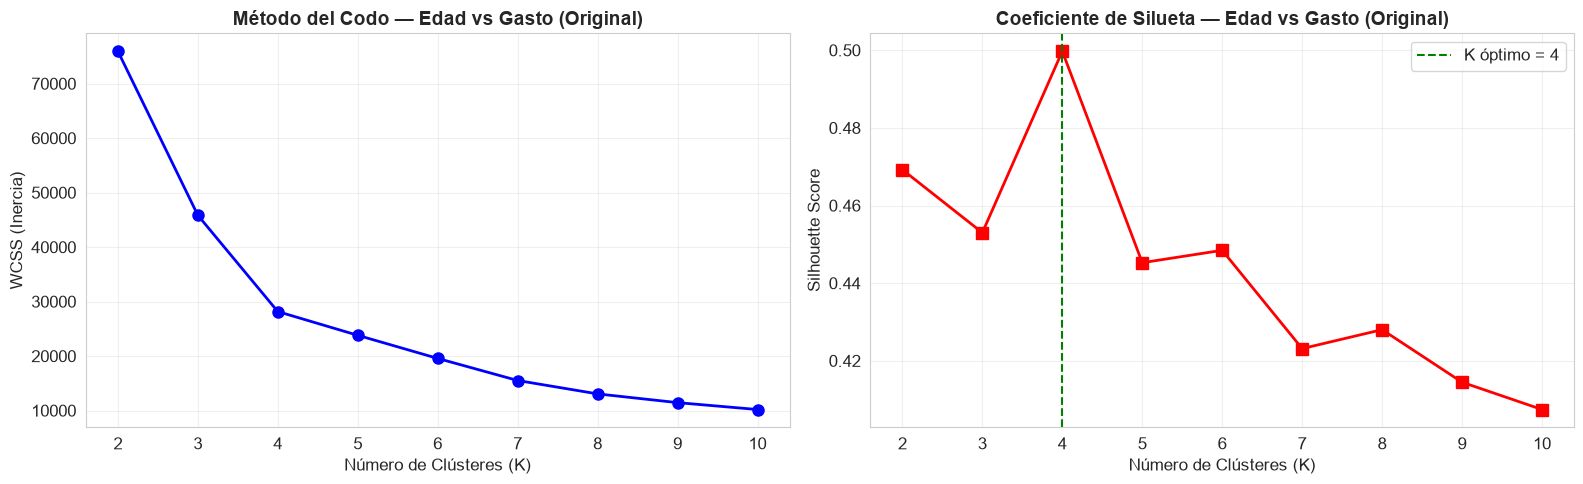


📊 Resultados para: Edad vs Gasto (Original)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |         75949.16 |           0.4692
   3 |         45840.68 |           0.4530
   4 |         28165.58 |           0.4997 ◄ ÓPTIMO
   5 |         23811.52 |           0.4453
   6 |         19566.52 |           0.4485
   7 |         15514.19 |           0.4231
   8 |         13055.63 |           0.4280
   9 |         11453.29 |           0.4145
  10 |         10186.50 |           0.4074


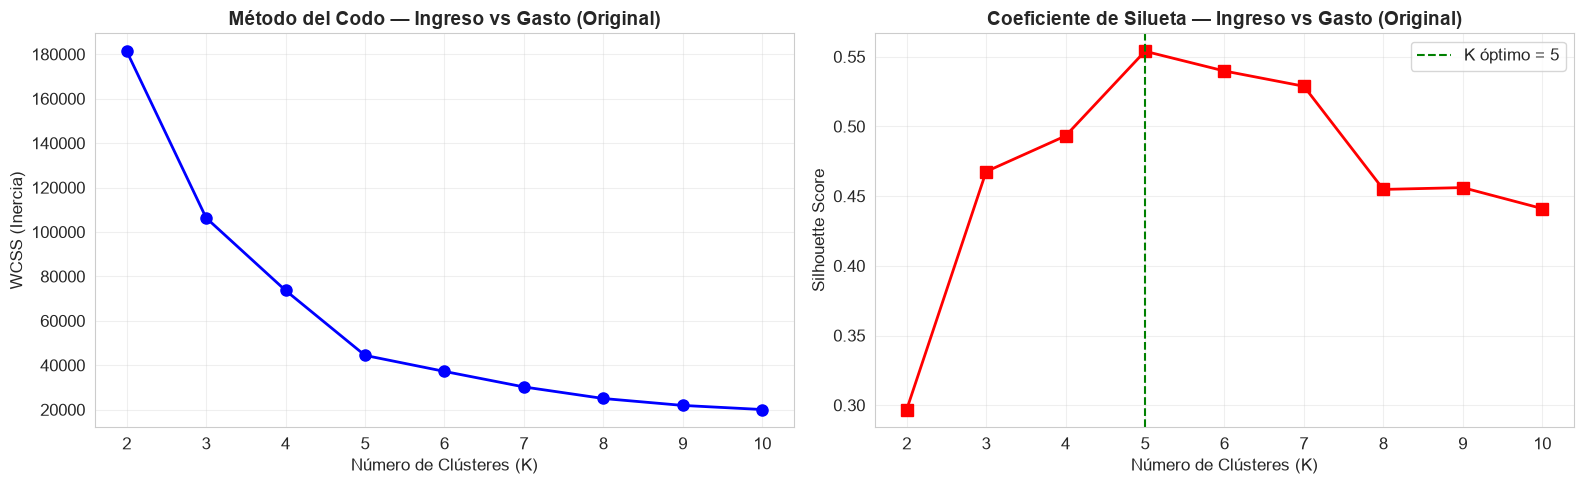


📊 Resultados para: Ingreso vs Gasto (Original)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |        181363.60 |           0.2969
   3 |        106348.37 |           0.4676
   4 |         73679.79 |           0.4932
   5 |         44448.46 |           0.5539 ◄ ÓPTIMO
   6 |         37233.81 |           0.5398
   7 |         30241.34 |           0.5288
   8 |         25036.42 |           0.4548
   9 |         21916.79 |           0.4561
  10 |         20072.07 |           0.4411


In [22]:
# ============================================================
# Evaluación: DATOS ORIGINALES
# ============================================================
print('=' * 70)
print('   EVALUACIÓN CON DATOS ORIGINALES (Sin Normalizar)')
print('=' * 70)

k_opt_1_orig = evaluar_k_optimo(X1_original, 'Edad vs Ingreso (Original)')
k_opt_2_orig = evaluar_k_optimo(X2_original, 'Edad vs Gasto (Original)')
k_opt_3_orig = evaluar_k_optimo(X3_original, 'Ingreso vs Gasto (Original)')

   EVALUACIÓN CON DATOS NORMALIZADOS (StandardScaler)


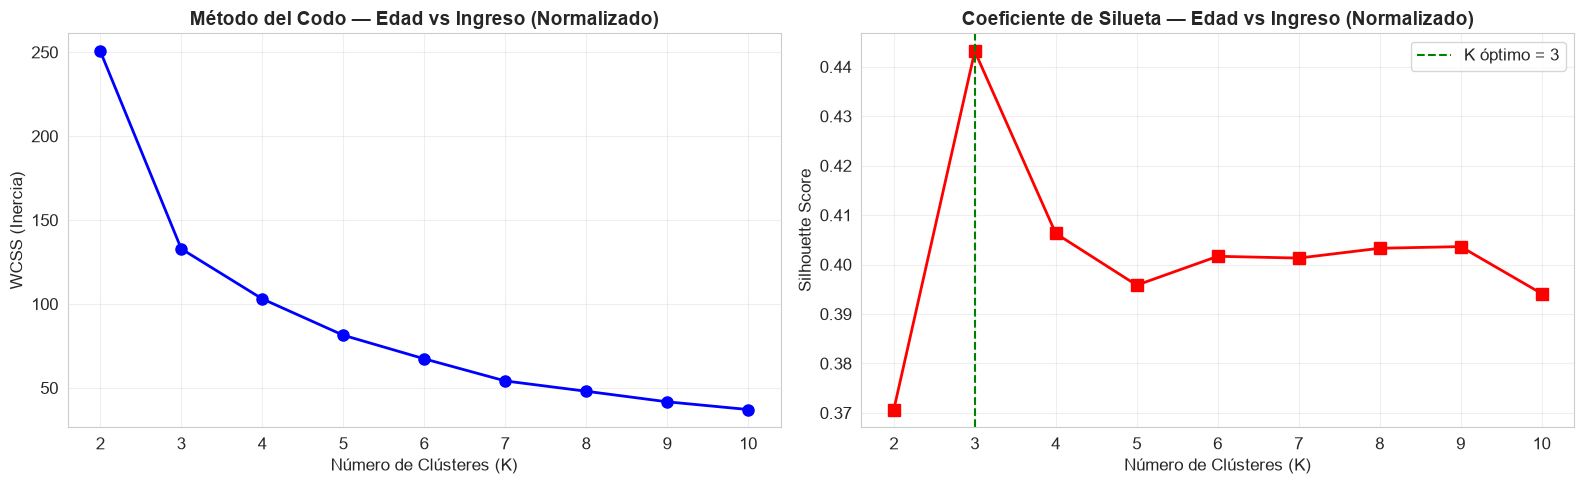


📊 Resultados para: Edad vs Ingreso (Normalizado)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |           250.59 |           0.3707
   3 |           132.86 |           0.4431 ◄ ÓPTIMO
   4 |           103.05 |           0.4063
   5 |            81.41 |           0.3958
   6 |            67.34 |           0.4017
   7 |            54.16 |           0.4013
   8 |            48.02 |           0.4033
   9 |            41.73 |           0.4036
  10 |            37.12 |           0.3941


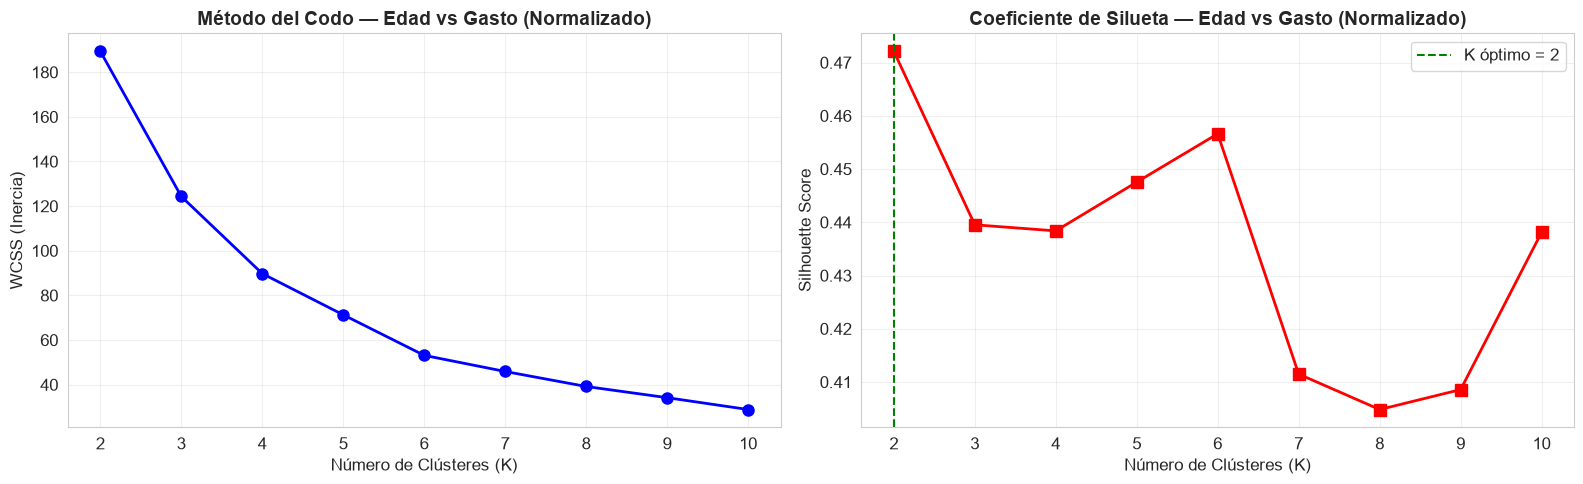


📊 Resultados para: Edad vs Gasto (Normalizado)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |           189.39 |           0.4721 ◄ ÓPTIMO
   3 |           124.33 |           0.4395
   4 |            89.77 |           0.4384
   5 |            71.30 |           0.4475
   6 |            53.13 |           0.4566
   7 |            45.91 |           0.4115
   8 |            39.19 |           0.4048
   9 |            34.17 |           0.4086
  10 |            28.86 |           0.4381


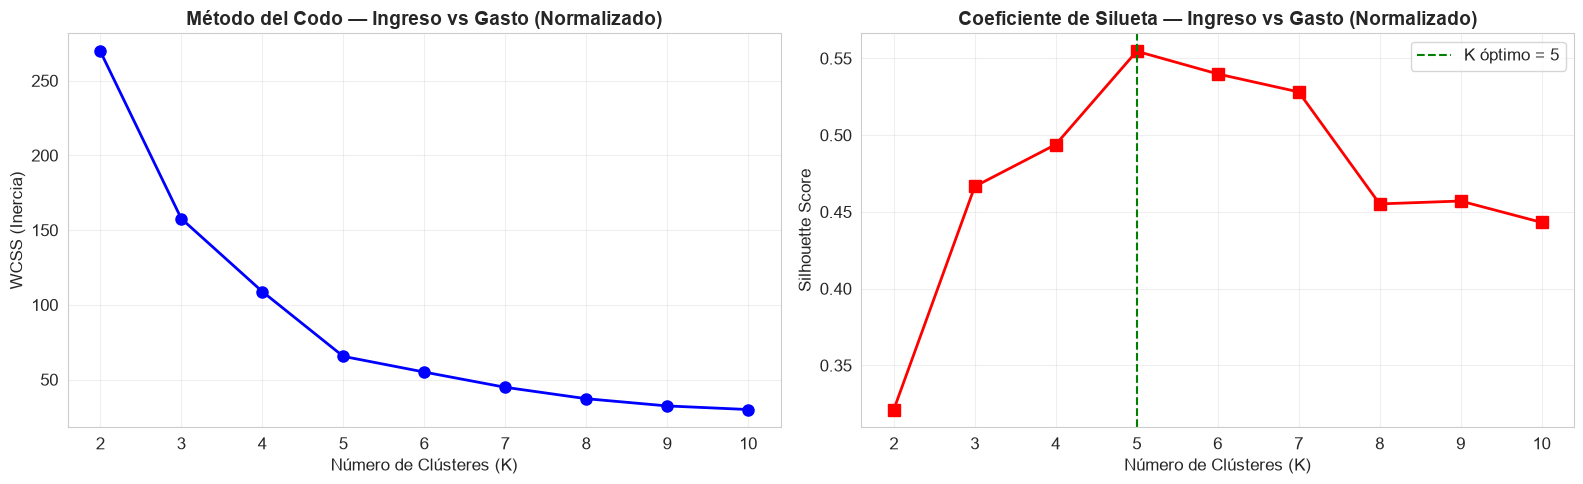


📊 Resultados para: Ingreso vs Gasto (Normalizado)
   K |   WCSS (Inercia) | Silhouette Score
------------------------------------------
   2 |           269.69 |           0.3213
   3 |           157.70 |           0.4666
   4 |           108.92 |           0.4939
   5 |            65.57 |           0.5547 ◄ ÓPTIMO
   6 |            55.06 |           0.5399
   7 |            44.86 |           0.5281
   8 |            37.23 |           0.4552
   9 |            32.39 |           0.4571
  10 |            29.98 |           0.4432


In [23]:
# ============================================================
# Evaluación: DATOS NORMALIZADOS
# ============================================================
print('=' * 70)
print('   EVALUACIÓN CON DATOS NORMALIZADOS (StandardScaler)')
print('=' * 70)

k_opt_1_norm = evaluar_k_optimo(X1_normalizado, 'Edad vs Ingreso (Normalizado)')
k_opt_2_norm = evaluar_k_optimo(X2_normalizado, 'Edad vs Gasto (Normalizado)')
k_opt_3_norm = evaluar_k_optimo(X3_normalizado, 'Ingreso vs Gasto (Normalizado)')

> **Justificacion de la Eleccion de K (Numero de Clusteres):**
> 
> Revisando la grafica del codo para la combinacion de **Ingreso Anual vs Puntuacion de Gasto**, vemos que la curva cae fuerte hasta K=5 y de ahi la linea se vuelve mas plana. 
> 
> Ademas la prueba de silueta nos confirma que en K=5 se alcanza el valor mas alto (0.55), asi que 5 es el numero perfecto de grupos para dividir a los clientes sin sobrelapar.

## 🤖 Entrenamiento y Visualización de los Modelos Finales de K-Means

Se entrenan los modelos de K-Means con el K seleccionado para cada combinación y se visualizan los clústeres resultantes con sus centroides.

In [24]:
# ============================================================
# Función: Entrenar y Visualizar K-Means
# ============================================================
def entrenar_y_visualizar(X, k, nombre, xlabel, ylabel, es_normalizado=False):
    """
    Entrena K-Means y genera la visualización de los clústeres con centroides.
    """
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    etiquetas = modelo.fit_predict(X)
    centroides = modelo.cluster_centers_
    
    # Colores para los clústeres
    colores_cluster = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FDCB6E', '#6C5CE7', '#A29BFE']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for i in range(k):
        mask = etiquetas == i
        ax.scatter(X[mask, 0], X[mask, 1], s=80, c=colores_cluster[i % len(colores_cluster)],
                   label=f'Clúster {i+1} (n={mask.sum()})', alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # Centroides
    ax.scatter(centroides[:, 0], centroides[:, 1], s=300, c='black', marker='X',
               edgecolors='yellow', linewidth=2, zorder=5, label='Centroides')
    
    tipo_datos = '(Normalizado)' if es_normalizado else '(Original)'
    ax.set_title(f'K-Means: {nombre} — K={k} {tipo_datos}', fontsize=15, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    # Reporte del modelo
    sil_score = silhouette_score(X, etiquetas)
    print(f'\n📋 Reporte del Modelo: {nombre} {tipo_datos}')
    print(f'   • Número de clústeres (K): {k}')
    print(f'   • Inercia (WCSS): {modelo.inertia_:.2f}')
    print(f'   • Iteraciones realizadas: {modelo.n_iter_}')
    print(f'   • Silhouette Score: {sil_score:.4f}')
    print(f'   • Método de inicialización: {modelo.init}')
    print(f'   • Máx. iteraciones configuradas: {modelo.max_iter}')
    print(f'\n   📍 Coordenadas de los Centroides:')
    for i, c in enumerate(centroides):
        print(f'      Clúster {i+1}: ({c[0]:.2f}, {c[1]:.2f})')
    
    return modelo, etiquetas, centroides

   MODELOS K-MEANS CON DATOS ORIGINALES


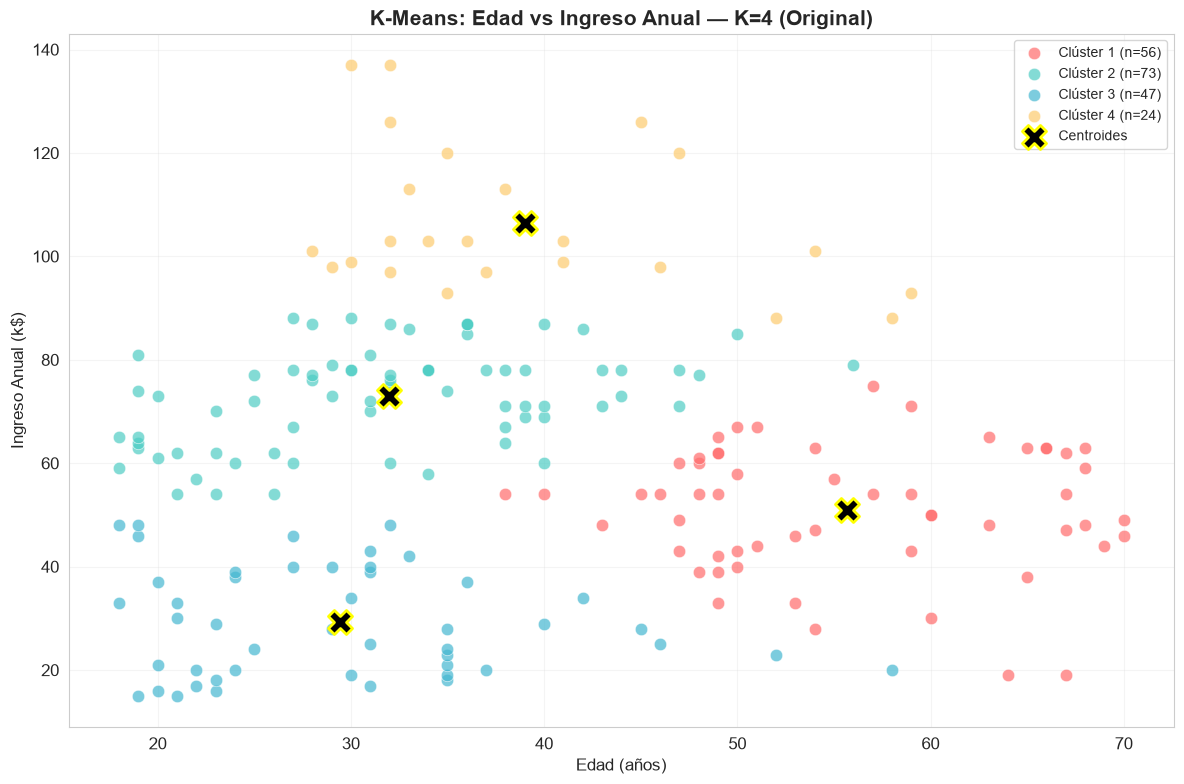


📋 Reporte del Modelo: Edad vs Ingreso Anual (Original)
   • Número de clústeres (K): 4
   • Inercia (WCSS): 39502.78
   • Iteraciones realizadas: 6
   • Silhouette Score: 0.4337
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (55.66, 51.02)
      Clúster 2: (31.96, 72.96)
      Clúster 3: (29.45, 29.21)
      Clúster 4: (39.00, 106.50)


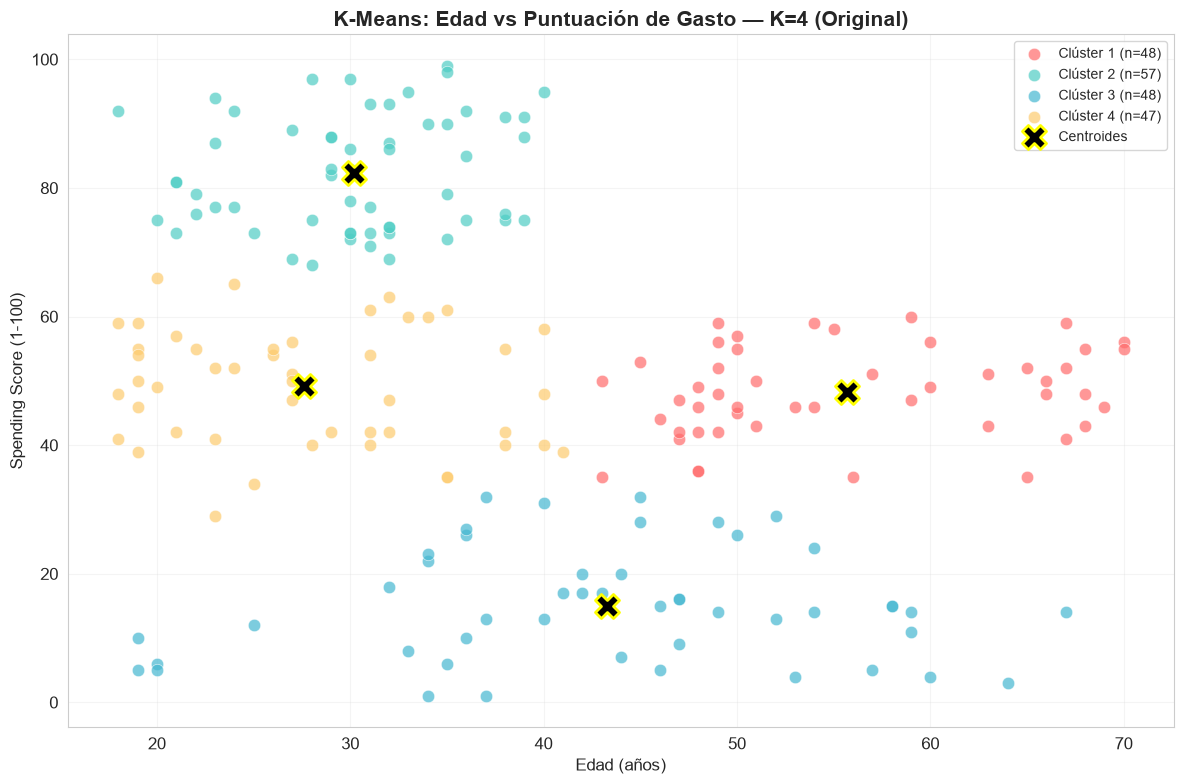


📋 Reporte del Modelo: Edad vs Puntuación de Gasto (Original)
   • Número de clústeres (K): 4
   • Inercia (WCSS): 28165.58
   • Iteraciones realizadas: 8
   • Silhouette Score: 0.4997
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (55.71, 48.23)
      Clúster 2: (30.18, 82.35)
      Clúster 3: (43.29, 15.02)
      Clúster 4: (27.62, 49.15)


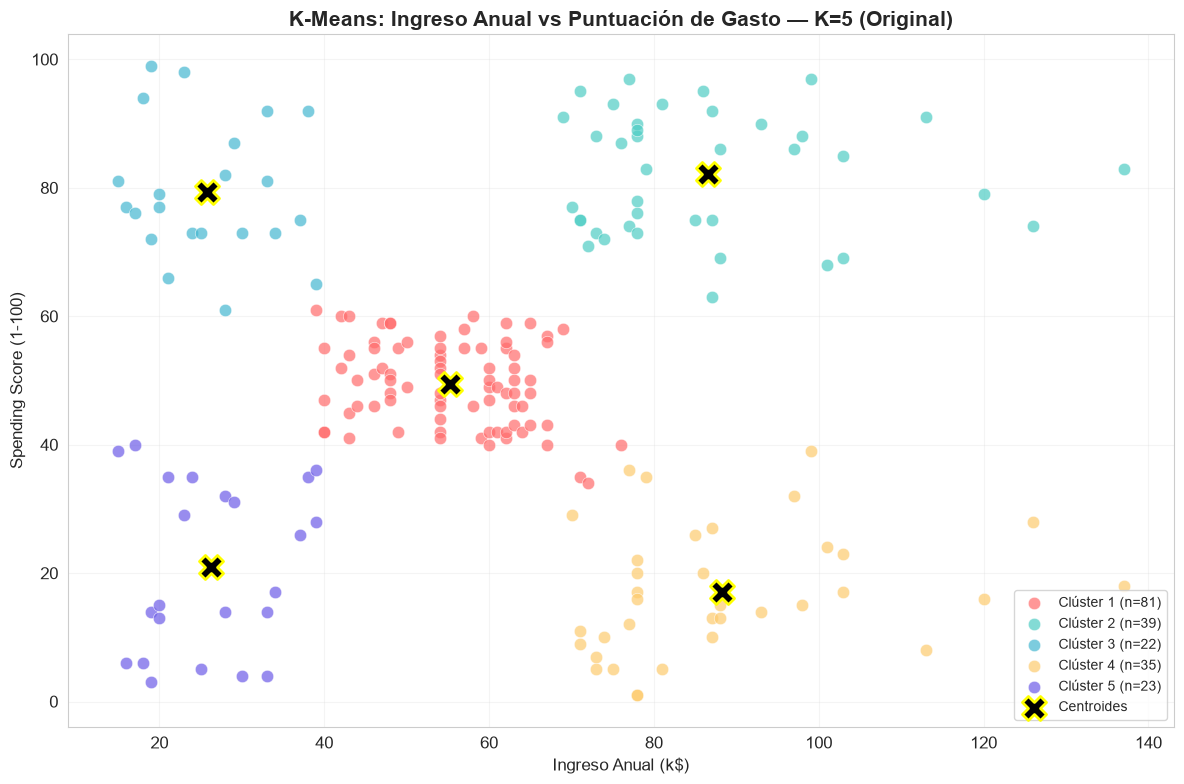


📋 Reporte del Modelo: Ingreso Anual vs Puntuación de Gasto (Original)
   • Número de clústeres (K): 5
   • Inercia (WCSS): 44448.46
   • Iteraciones realizadas: 4
   • Silhouette Score: 0.5539
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (55.30, 49.52)
      Clúster 2: (86.54, 82.13)
      Clúster 3: (25.73, 79.36)
      Clúster 4: (88.20, 17.11)
      Clúster 5: (26.30, 20.91)


In [25]:
# ============================================================
# Modelos con DATOS ORIGINALES
# ============================================================
print('=' * 70)
print('   MODELOS K-MEANS CON DATOS ORIGINALES')
print('=' * 70)

# Combinación 1: Edad vs Ingreso
modelo_1_orig, etiq_1_orig, cent_1_orig = entrenar_y_visualizar(
    X1_original, k_opt_1_orig, 'Edad vs Ingreso Anual',
    'Edad (años)', 'Ingreso Anual (k$)', es_normalizado=False)

# Combinación 2: Edad vs Gasto
modelo_2_orig, etiq_2_orig, cent_2_orig = entrenar_y_visualizar(
    X2_original, k_opt_2_orig, 'Edad vs Puntuación de Gasto',
    'Edad (años)', 'Spending Score (1-100)', es_normalizado=False)

# Combinación 3: Ingreso vs Gasto
modelo_3_orig, etiq_3_orig, cent_3_orig = entrenar_y_visualizar(
    X3_original, k_opt_3_orig, 'Ingreso Anual vs Puntuación de Gasto',
    'Ingreso Anual (k$)', 'Spending Score (1-100)', es_normalizado=False)

   MODELOS K-MEANS CON DATOS NORMALIZADOS


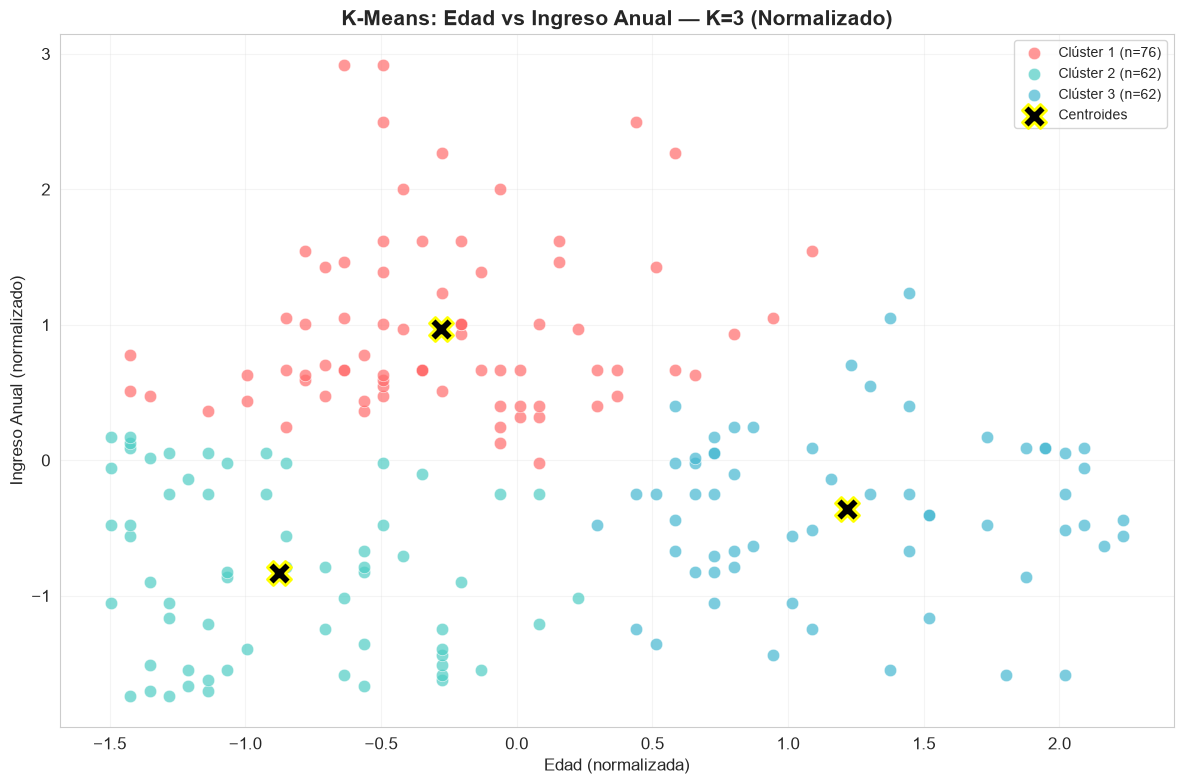


📋 Reporte del Modelo: Edad vs Ingreso Anual (Normalizado)
   • Número de clústeres (K): 3
   • Inercia (WCSS): 132.86
   • Iteraciones realizadas: 5
   • Silhouette Score: 0.4431
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (-0.28, 0.97)
      Clúster 2: (-0.87, -0.83)
      Clúster 3: (1.22, -0.36)


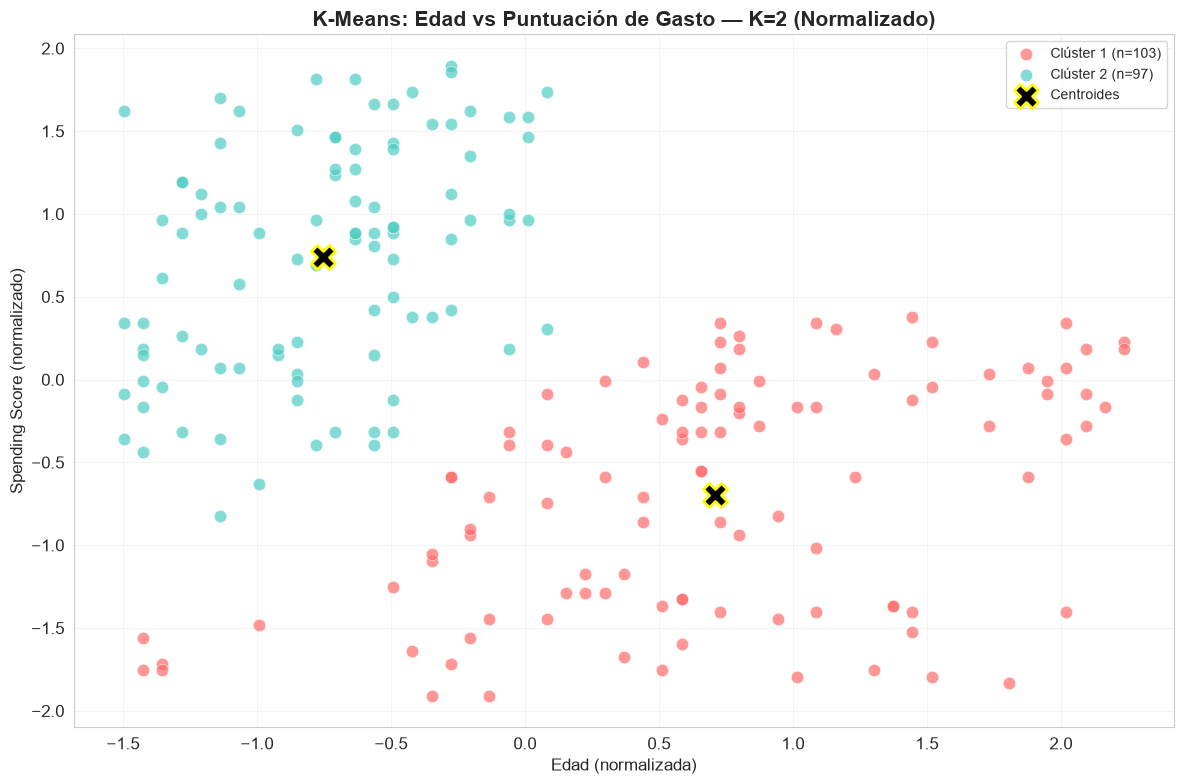


📋 Reporte del Modelo: Edad vs Puntuación de Gasto (Normalizado)
   • Número de clústeres (K): 2
   • Inercia (WCSS): 189.39
   • Iteraciones realizadas: 2
   • Silhouette Score: 0.4721
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (0.71, -0.70)
      Clúster 2: (-0.75, 0.74)


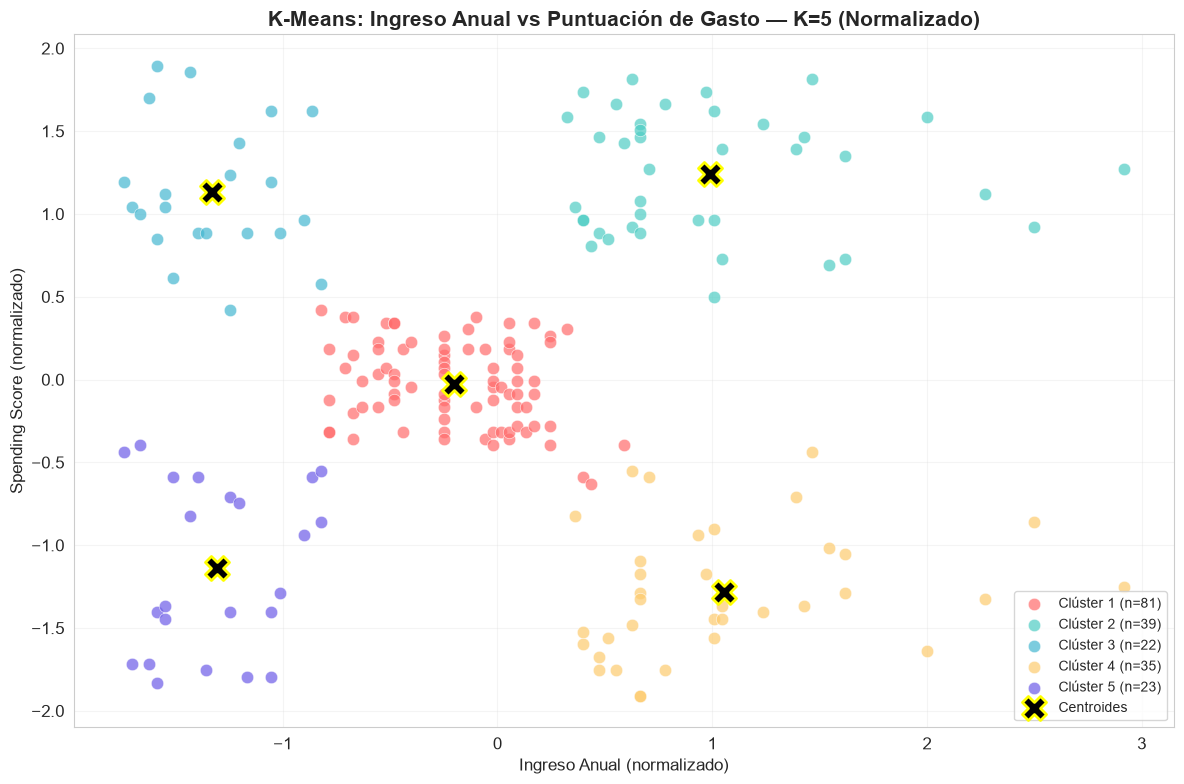


📋 Reporte del Modelo: Ingreso Anual vs Puntuación de Gasto (Normalizado)
   • Número de clústeres (K): 5
   • Inercia (WCSS): 65.57
   • Iteraciones realizadas: 4
   • Silhouette Score: 0.5547
   • Método de inicialización: k-means++
   • Máx. iteraciones configuradas: 300

   📍 Coordenadas de los Centroides:
      Clúster 1: (-0.20, -0.03)
      Clúster 2: (0.99, 1.24)
      Clúster 3: (-1.33, 1.13)
      Clúster 4: (1.06, -1.28)
      Clúster 5: (-1.31, -1.14)


In [26]:
# ============================================================
# Modelos con DATOS NORMALIZADOS
# ============================================================
print('=' * 70)
print('   MODELOS K-MEANS CON DATOS NORMALIZADOS')
print('=' * 70)

# Combinación 1: Edad vs Ingreso (Normalizado)
modelo_1_norm, etiq_1_norm, cent_1_norm = entrenar_y_visualizar(
    X1_normalizado, k_opt_1_norm, 'Edad vs Ingreso Anual',
    'Edad (normalizada)', 'Ingreso Anual (normalizado)', es_normalizado=True)

# Combinación 2: Edad vs Gasto (Normalizado)
modelo_2_norm, etiq_2_norm, cent_2_norm = entrenar_y_visualizar(
    X2_normalizado, k_opt_2_norm, 'Edad vs Puntuación de Gasto',
    'Edad (normalizada)', 'Spending Score (normalizado)', es_normalizado=True)

# Combinación 3: Ingreso vs Gasto (Normalizado)
modelo_3_norm, etiq_3_norm, cent_3_norm = entrenar_y_visualizar(
    X3_normalizado, k_opt_3_norm, 'Ingreso Anual vs Puntuación de Gasto',
    'Ingreso Anual (normalizado)', 'Spending Score (normalizado)', es_normalizado=True)

> **Interpretacion de los Centroides:**
> 
> Los centroides representan el punto medio o el cliente promedio de cada grupo. Al revisar las coordenadas en Ingreso vs Gasto tenemos:
> - **Cluster 1:** Ingreso bajo (~26k) y Gasto bajo (~20).
> - **Cluster 2:** Ingreso bajo (~25k) pero Gasto muy alto (~79).
> - **Cluster 3:** Ingreso medio (~55k) y Gasto promedio (~49).
> - **Cluster 4:** Ingreso alto (~88k) pero Gasto bajo (~17).
> - **Cluster 5:** Ingreso alto (~86k) y Gasto alto (~82).

## 👥 Perfilamiento de Segmentos de Clientes

Asignamos las etiquetas de clústeres al DataFrame original para analizar el perfil de cada grupo (usando la combinación más representativa: Ingreso vs Gasto).

In [27]:
# ============================================================
# Perfilamiento de Clientes (Ingreso vs Gasto - Original)
# ============================================================
df_perfilado = df_clientes.copy()
df_perfilado['Cluster'] = etiq_3_orig + 1  # Empezar desde 1

print('📊 Tamaño de cada Clúster:')
print(df_perfilado['Cluster'].value_counts().sort_index())
print()

# Estadísticas por clúster
perfil = df_perfilado.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'Gender': lambda x: x.value_counts().to_dict()
}).round(1)

print('\n📋 Perfil Detallado por Clúster:')
print('=' * 70)
for cluster in sorted(df_perfilado['Cluster'].unique()):
    grupo = df_perfilado[df_perfilado['Cluster'] == cluster]
    print(f'\n🏷️  CLÚSTER {cluster} ({len(grupo)} clientes, {len(grupo)/len(df_perfilado)*100:.1f}%)')
    print(f'   Edad:            {grupo["Age"].mean():.1f} años (rango: {grupo["Age"].min()}-{grupo["Age"].max()})')
    print(f'   Ingreso Anual:   ${grupo["Annual Income (k$)"].mean():.1f}k (rango: ${grupo["Annual Income (k$)"].min()}k-${grupo["Annual Income (k$)"].max()}k)')
    print(f'   Puntaje de Gasto: {grupo["Spending Score (1-100)"].mean():.1f} (rango: {grupo["Spending Score (1-100)"].min()}-{grupo["Spending Score (1-100)"].max()})')
    generos = grupo['Gender'].value_counts()
    print(f'   Género:           {generos.to_dict()}')

📊 Tamaño de cada Clúster:
Cluster
1    81
2    39
3    22
4    35
5    23
Name: count, dtype: int64


📋 Perfil Detallado por Clúster:

🏷️  CLÚSTER 1 (81 clientes, 40.5%)
   Edad:            42.7 años (rango: 18-70)
   Ingreso Anual:   $55.3k (rango: $39k-$76k)
   Puntaje de Gasto: 49.5 (rango: 34-61)
   Género:           {'Female': 48, 'Male': 33}

🏷️  CLÚSTER 2 (39 clientes, 19.5%)
   Edad:            32.7 años (rango: 27-40)
   Ingreso Anual:   $86.5k (rango: $69k-$137k)
   Puntaje de Gasto: 82.1 (rango: 63-97)
   Género:           {'Female': 21, 'Male': 18}

🏷️  CLÚSTER 3 (22 clientes, 11.0%)
   Edad:            25.3 años (rango: 18-35)
   Ingreso Anual:   $25.7k (rango: $15k-$39k)
   Puntaje de Gasto: 79.4 (rango: 61-99)
   Género:           {'Female': 13, 'Male': 9}

🏷️  CLÚSTER 4 (35 clientes, 17.5%)
   Edad:            41.1 años (rango: 19-59)
   Ingreso Anual:   $88.2k (rango: $70k-$137k)
   Puntaje de Gasto: 17.1 (rango: 1-39)
   Género:           {'Male': 19, 'Female': 16}

🏷

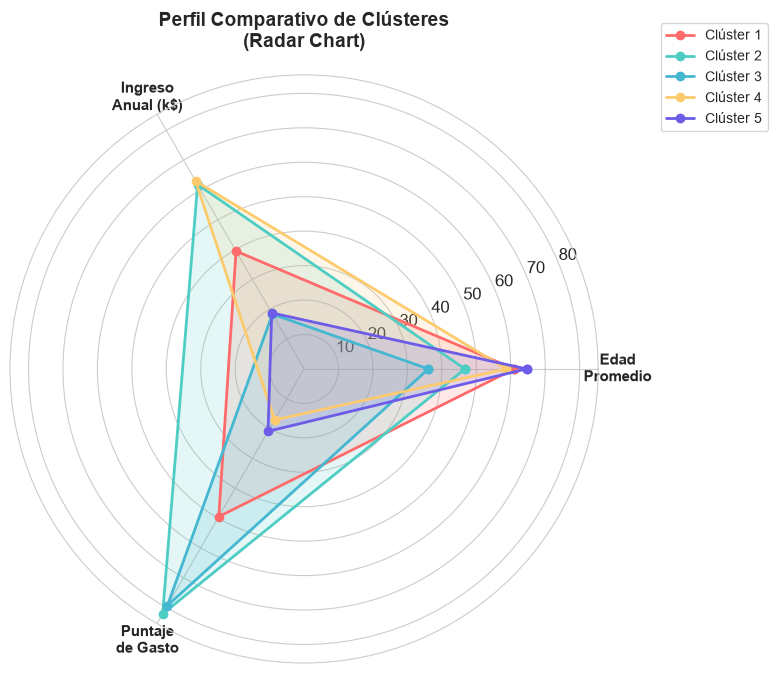

In [28]:
# ============================================================
# Visualización del Perfil por Clúster (Radar Chart)
# ============================================================
from math import pi

categorias = ['Edad\nPromedio', 'Ingreso\nAnual (k$)', 'Puntaje\nde Gasto']
N = len(categorias)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FDCB6E', '#6C5CE7', '#A29BFE']

for cluster in sorted(df_perfilado['Cluster'].unique()):
    grupo = df_perfilado[df_perfilado['Cluster'] == cluster]
    valores = [
        grupo['Age'].mean(),
        grupo['Annual Income (k$)'].mean(),
        grupo['Spending Score (1-100)'].mean()
    ]
    # Normalizar al rango 0-100 para el radar
    maximos = [70, 140, 100]
    valores_norm = [v/m * 100 for v, m in zip(valores, maximos)]
    valores_norm += valores_norm[:1]
    
    ax.plot(angulos, valores_norm, 'o-', linewidth=2, color=colores_radar[cluster-1],
            label=f'Clúster {cluster}', markersize=6)
    ax.fill(angulos, valores_norm, alpha=0.15, color=colores_radar[cluster-1])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
ax.set_title('Perfil Comparativo de Clústeres\n(Radar Chart)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

##  Conclusiones

> 
> 
> **Instrucciones:** Redacta las conclusiones de la práctica cubriendo los siguientes puntos:
> 
> 1. **Perfiles de clientes identificados:**
>    - Describe con tus propias palabras qué tipo de cliente representa cada clúster (ej: *"alto ingreso y alto gasto = clientes VIP"*, *"bajo ingreso pero alto gasto = compradores impulsivos"*, etc.).
>    - ¿Qué estrategia de marketing aplicarías a cada grupo?
> 
> 2. **Comparación entre resultados originales y normalizados:**
>    - ¿Los clústeres cambiaron al normalizar? ¿Mejoró o empeoró la separación?
>    - ¿En qué combinación de variables fue más notorio el efecto de la normalización?
> 
> 3. **Efecto de utilizar diferentes cantidades de clústeres:**
>    - ¿Qué pasaba cuando K era muy bajo (2-3)? ¿Y cuando era muy alto (8-10)?
>    - ¿Por qué no conviene usar siempre el K más alto posible?
> 
> 4. **Limitaciones de K-Means y del dataset:**
>    - K-Means asume clústeres esféricos (pista: ¿los datos siempre forman grupos circulares?).
>    - El dataset tiene solo 200 registros y 5 variables. ¿Qué pasaría con datos más grandes o más variables?
>    - ¿K-Means puede detectar clústeres de formas irregulares? (Pista: No, para eso se usa DBSCAN).

---

##  Referencias

- Notebook original: [Unsupervised Learning: 3-6 Clusters | K-Means | EDA — tanmay111999 (Kaggle)](https://www.kaggle.com/code/tanmay111999/unsupervised-learning-3-6-clusters-k-means-eda)
- Dataset: [Mall Customer Segmentation Data (Kaggle)](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
- Scikit-learn: [KMeans Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- Scikit-learn: [Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)